# Camera Calibration

## Basic Principles

After completing vision system hardware selection, camera calibration is needed to obtain accurate camera parameters. The purpose of camera calibration is to determine the camera's intrinsic and extrinsic parameters. Intrinsic parameters include focal length, principal point position, and distortion coefficients, while extrinsic parameters describe the camera's position and orientation in the world coordinate system.

Here we introduce a simple camera calibration method called Zhang's calibration method, proposed by Dr. Zhengyou Zhang in 1999, which received the IEEE Test of Time Award and is still a widely used calibration method today. This method uses a checkerboard pattern with known dimensions as a calibration board, as shown below.

You can use the following prompt:

**Use OpenCV to draw a checkerboard image for camera calibration and display it. To prevent any character encoding issues, please ensure that all code and comments are written entirely in English.**

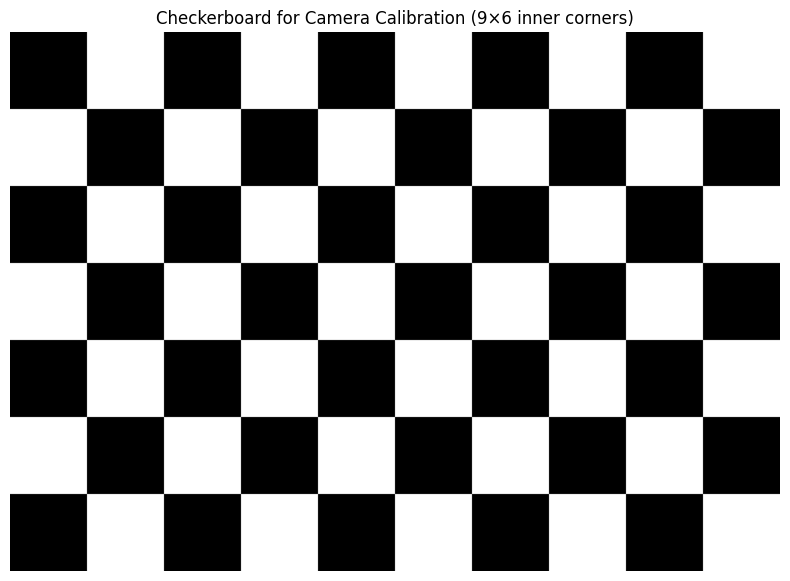

In [ ]:
# Add your code here

In the checkerboard image above, place the world coordinate origin at the top-left corner point, with the $X_w$ axis pointing horizontally to the right, the $Y_w$ axis pointing vertically downward, and the $Z_w$ axis perpendicular to the image plane pointing inward. Assuming each small square has side length $s$, then each corner point on the checkerboard can have its world coordinates expressed as $(i \cdot s, j \cdot s, 0)$, where $i$ and $j$ are the indices of the corner point in the horizontal and vertical directions, respectively.

At this point, according to the perspective projection model, the world coordinates of each corner point on the checkerboard can be mapped to pixel coordinates on the image plane. Assuming there are $n$ corner points on the checkerboard with world coordinates $(X_{w_i}, Y_{w_i}, 0)$ and corresponding pixel coordinates $(u_i, v_i)$, we can obtain the following system of equations:

 $$
    \begin{bmatrix}
    u_i \\
    v_j \\
    1
    \end{bmatrix}
    =
    K
    \begin{bmatrix}
    R & T
    \end{bmatrix}
    \begin{bmatrix}
    X_{w_i} \\
    Y_{w_j} \\
    0 \\
    1
    \end{bmatrix}
    $$

Since the $Z_w$ coordinate is always 0, this can be simplified to:
    $$  
    \begin{bmatrix}
    u_i \\
    v_j \\
    1
    \end{bmatrix}
    =
    K
    \begin{bmatrix}
    \bold{r}_1 & \bold{r}_2 & T
    \end{bmatrix}
    \begin{bmatrix}
    X_{w_i} \\
    Y_{w_j} \\
    1
    \end{bmatrix}
    $$

Let
    $
    H = K
    \begin{bmatrix}
    \bold{r}_1 & \bold{r}_2 & T
    \end{bmatrix}
    $

Then the above equation can be simplified to:
    $$
    \begin{bmatrix}
    u_i \\
    v_j \\
    1
    \end{bmatrix}
    =
    H
    \begin{bmatrix}
    X_{w_i} \\
    Y_{w_j} \\
    1
    \end{bmatrix}
    $$

In the above equation, $H$ is a $3 \times 3$ matrix with 8 independent parameters. To determine these parameters, at least 8 equations need to be established, which requires finding at least 8 correspondences between pixel coordinates in the calibration board image and world coordinates on the checkerboard. This can be achieved by analyzing one calibration image. Given one calibration board image, matrix $H$ can be calculated using the above equation. To calculate the camera's intrinsic and extrinsic parameters from $H$, further analysis of the relationship between matrix $H$ and the camera's intrinsic and extrinsic parameters is needed.

Decomposing $H$ into three columns, denoted as $\bold{h}_1$, $\bold{h}_2$, and $\bold{h}_3$, we have:

$$
\begin{bmatrix}
\bold{h}_1 & \bold{h}_2 & \bold{h}_3
\end{bmatrix}= \lambda K
\begin{bmatrix} 
\bold{r}_1 & \bold{r}_2 & T
\end{bmatrix}
$$

Based on the orthonormal relationship in the rotation matrix, we can obtain:

$$
\begin{aligned}
\bold{h}_1^T K^{-T}  K^{-1} \bold{h}_2 &= 0 \\
\bold{h}_1^T K^{-T}  K^{-1} \bold{h}_1 &= \bold{h}_2^T K^{-T}  K^{-1} \bold{h}_2
\end{aligned}
$$

Now if we let $B = K^{-T}  K^{-1}$, then $b=(B_{11}, B_{12}, B_{22}, B_{13}, B_{23}, B_{33})$, and we obtain the system of equations:

$$\begin{aligned}
v_{12}^T b &= 0 \\      
(v_{11} - v_{22})^T b &= 0
\end{aligned}$$

This means that given one calibration board image, matrix $M$ can be calculated, yielding 2 equations about the camera intrinsic parameter matrix. In vector $b$, there are 6 unknowns, so at least 3 calibration board images are needed to solve for $b$. To ensure the equations are independent, calibration board images must be captured from different angles and positions. After solving for the camera intrinsic parameter matrix from $b$, the camera extrinsic parameter matrix can be further derived.

However, since the above derivation did not involve camera distortion coefficients, after obtaining the camera's intrinsic and extrinsic parameters, **bundle adjustment** using nonlinear optimization methods is needed to obtain more accurate results.

Assuming there are $N$ 3D points in the world coordinate system, denoted as ${}^W\mathbf{x}_i$, where $i = 1, 2, \dots, N$. These points correspond to $N$ 2D observation points in $K$ images, denoted as ${}^S_i\mathbf{x}_k$, where $i = 1, 2, \dots, N$ and $k = 1, 2, \dots, K$.

Also assume the camera intrinsic parameters are $\{c_j\}$, and the extrinsic parameters (i.e., the pose of the camera in the $k$-th frame relative to the world coordinate system) are ${}^C_k\mathbf{T}_W$, for $k = 1, \dots, K$.

Then, **Bundle Adjustment** can be expressed as the following reprojection error minimization problem:

$$
\min_{\{{}^W\mathbf{x}_i\}, \{c_j\}, \{{}^C_k\mathbf{T}_W\}} \sum_{k=1}^{K} \sum_{i=1}^{N} \left\| {}^S_i\mathbf{x}_k - \pi\left({}^C_k\mathbf{T}_W \cdot {}^W\mathbf{x}_i; \{c_j\}\right) \right\|^2
$$

Where $\pi(\cdot)$ represents the camera projection function, which projects 3D points onto the image plane through intrinsic and extrinsic parameters.

## Hands-on Practice

First, copy the Python code for the Camera class from the perspective projection model section above into DeepSeek so that the large language model becomes familiar with its attributes and methods. Then, use matplotlib 3D to generate a 3D point cloud of a camera calibration board in the world coordinate system. You can use the following prompt:

**Use matplotlib 3D to generate a 3D point cloud of a camera calibration board in the world coordinate system. The calibration board has 6 rows and 9 columns of corner points, and each small square has a side length of 0.05 meters. To prevent any character encoding issues, please ensure that all code and comments are written entirely in English.**

Generating basic calibration board...


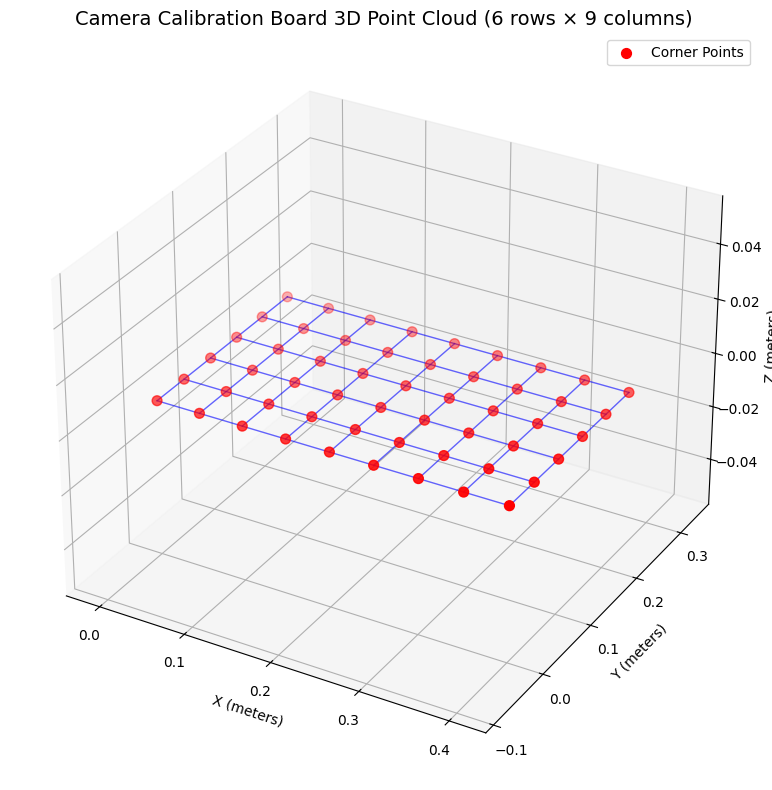

Number of corner points: 54
Board size: 0.400 meters × 0.250 meters

First 5 corner points coordinates:
Point 1: (0.000, 0.000, 0.000)
Point 2: (0.050, 0.000, 0.000)
Point 3: (0.100, 0.000, 0.000)
Point 4: (0.150, 0.000, 0.000)
Point 5: (0.200, 0.000, 0.000)

Generating calibration boards with different poses...


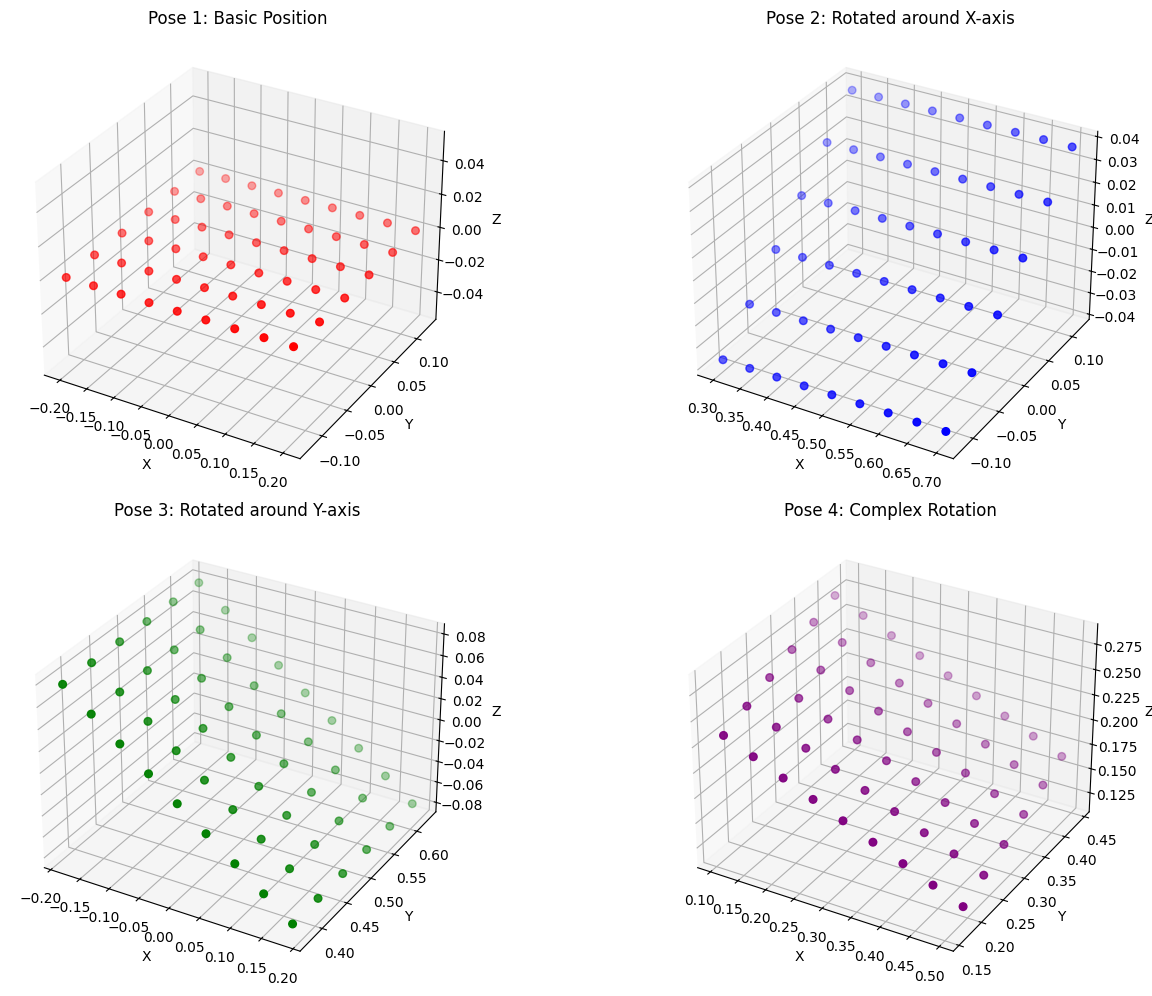


Point cloud shape: (54, 3)
Point cloud data type: float64
X coordinate range: [0.000, 0.400]
Y coordinate range: [0.000, 0.250]
Z coordinate range: [0.000, 0.000]


In [ ]:
# Add your code here

The camera class is defined as the following:

In [33]:
import numpy as np
import matplotlib.pyplot as plt

class Camera:
    def __init__(self, f, u0, v0, du, dv, k1=0, k2=0):
        """
        初始化相机参数
        
        参数:
        f: 焦距 (mm)
        u0, v0: 主点坐标 (像素)
        du, dv: 像元尺寸 (mm/pixel)
        k1, k2: 径向畸变系数
        """
        self.f = f  # 焦距
        self.u0 = u0  # 主点u坐标
        self.v0 = v0  # 主点v坐标
        self.du = du  # u方向像元尺寸
        self.dv = dv  # v方向像元尺寸
        self.k1 = k1  # 径向畸变系数1
        self.k2 = k2  # 径向畸变系数2
        
    def perspective_projection(self, points_3d, alpha, beta, theta, T):
        """
        透视投影方法：将三维点云投影到二维图像平面
        
        参数:
        points_3d: 三维点云，形状为 (n, 3) 的numpy数组
        alpha, beta, theta: 欧拉角 (弧度)
        T: 平移向量，形状为 (3,) 的numpy数组
        
        返回:
        points_2d: 二维像素坐标，形状为 (n, 2) 的numpy数组
        valid_indices: 有效点的索引
        """
        # 构建旋转矩阵 (Z-Y-X欧拉角)
        Rz = np.array([[np.cos(alpha), -np.sin(alpha), 0],
                       [np.sin(alpha), np.cos(alpha), 0],
                       [0, 0, 1]])
        
        Ry = np.array([[np.cos(beta), 0, np.sin(beta)],
                       [0, 1, 0],
                       [-np.sin(beta), 0, np.cos(beta)]])
        
        Rx = np.array([[1, 0, 0],
                       [0, np.cos(theta), -np.sin(theta)],
                       [0, np.sin(theta), np.cos(theta)]])
        
        R = Rz @ Ry @ Rx
        
        # 转换点到相机坐标系
        points_cam = (R @ points_3d.T).T + T
        
        # 筛选出相机前方的点 (z>0)
        valid_indices = points_cam[:, 2] > 0
        points_cam = points_cam[valid_indices]
        
        if len(points_cam) == 0:
            return np.array([]), valid_indices
        
        # 归一化图像坐标
        x_norm = points_cam[:, 0] / points_cam[:, 2]
        y_norm = points_cam[:, 1] / points_cam[:, 2]
        
        # 应用径向畸变
        r2 = x_norm**2 + y_norm**2
        distortion = 1 + self.k1 * r2 + self.k2 * r2**2
        x_distorted = x_norm * distortion
        y_distorted = y_norm * distortion
        
        # 转换为像素坐标
        u = self.f / self.du * x_distorted + self.u0
        v = self.f / self.dv * y_distorted + self.v0
        
        # 组合结果
        points_2d = np.column_stack((u, v))
        
        return points_2d, valid_indices
    
    def _draw_circle(self, image, center_u, center_v, radius=3):
        """
        在图像上以指定位置为中心绘制一个圆
        
        参数:
        image: 图像数组
        center_u, center_v: 圆心坐标
        radius: 圆的半径（像素）
        """
        height, width = image.shape
        center_u_int = int(round(center_u))
        center_v_int = int(round(center_v))
        
        # 确定圆的边界范围
        u_min = max(0, center_u_int - radius)
        u_max = min(width, center_u_int + radius + 1)
        v_min = max(0, center_v_int - radius)
        v_max = min(height, center_v_int + radius + 1)
        
        # 在圆的范围内设置像素值
        for v in range(v_min, v_max):
            for u in range(u_min, u_max):
                # 计算当前像素到圆心的距离
                distance = np.sqrt((u - center_u_int)**2 + (v - center_v_int)**2)
                if distance <= radius:
                    image[v, u] = 1
    
    def draw_image(self, points_2d, image_size=(1024, 768), point_radius=3):
        """
        在图像平面上绘制投影点，每个点绘制为圆形
        
        参数:
        points_2d: 二维像素坐标，形状为 (n, 2) 的numpy数组
        image_size: 图像尺寸 (宽度, 高度)
        point_radius: 点的半径（像素）
        
        返回:
        image: 生成的图像数组
        """
        if len(points_2d) == 0:
            print("No valid projection points to display")
            return np.zeros((image_size[1], image_size[0]))
        
        # 创建空白图像
        image = np.zeros((image_size[1], image_size[0]))
        
        # 筛选在图像范围内的点
        valid_points = []
        for point in points_2d:
            u, v = point
            if 0 <= u < image_size[0] and 0 <= v < image_size[1]:
                valid_points.append(point)
        
        valid_points = np.array(valid_points)
        
        if len(valid_points) == 0:
            print("All projection points are outside the image range")
            return image
        
        # 为每个有效点绘制圆形
        for point in valid_points:
            u, v = point
            self._draw_circle(image, u, v, point_radius)
        
        # 显示图像
        plt.figure(figsize=(6, 4))
        plt.imshow(image, cmap='gray', vmin=0, vmax=1)
        plt.title(f'Camera Projection Image\n({len(valid_points)} points with radius {point_radius} pixels)')
        plt.xlabel('u (pixels)')
        plt.ylabel('v (pixels)')
        #plt.colorbar(label='Intensity')
        plt.grid(False)
        plt.tight_layout()
        plt.show()
        
        print(f"Successfully drew {len(valid_points)} circular points on the image")
        print(f"Image dimensions: {image_size[0]} x {image_size[1]} pixels")
        print(f"Radius of each point: {point_radius} pixels")
        
        return image

Next, instantiate a Camera object, set its intrinsic and extrinsic parameters, then capture images of the calibration board in different poses and display the captured images. Based on the pixel coordinates obtained from each capture, call OpenCV functions to calculate the camera's intrinsic and extrinsic parameters. Finally, compare the calculated intrinsic and extrinsic parameters with the originally set parameters. You can use the following prompt:

**Instantiate a Camera object, set its intrinsic and extrinsic parameters, then capture images of the calibration board in different poses and display the captured images. Based on the pixel coordinates obtained from each capture, call OpenCV functions to calculate the camera's intrinsic and extrinsic parameters. Finally, compare the calculated intrinsic and extrinsic parameters with the originally set parameters. To prevent any character encoding issues, please ensure that all code and comments are written entirely in English.**

Generating calibration images and collecting data...


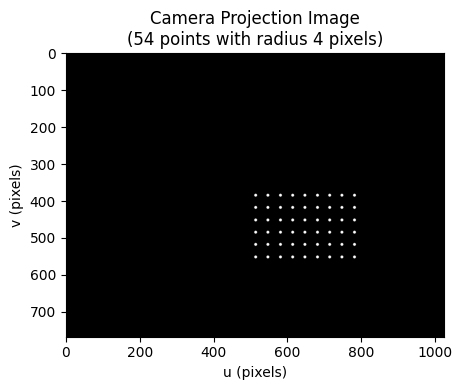

Successfully drew 54 circular points on the image
Image dimensions: 1024 x 768 pixels
Radius of each point: 4 pixels
Pose 1: 54 valid points


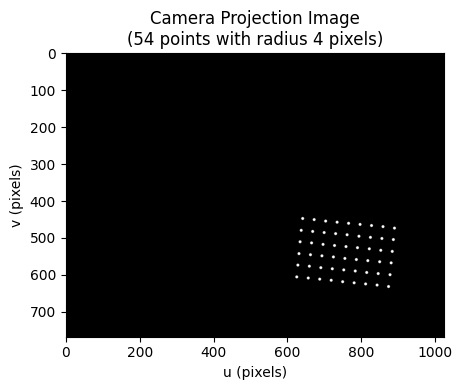

Successfully drew 54 circular points on the image
Image dimensions: 1024 x 768 pixels
Radius of each point: 4 pixels
Pose 2: 54 valid points


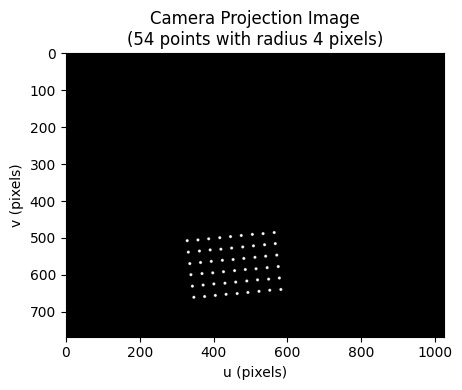

Successfully drew 54 circular points on the image
Image dimensions: 1024 x 768 pixels
Radius of each point: 4 pixels
Pose 3: 54 valid points


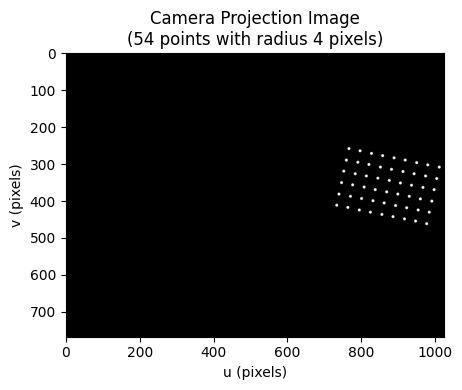

Successfully drew 54 circular points on the image
Image dimensions: 1024 x 768 pixels
Radius of each point: 4 pixels
Pose 4: 54 valid points


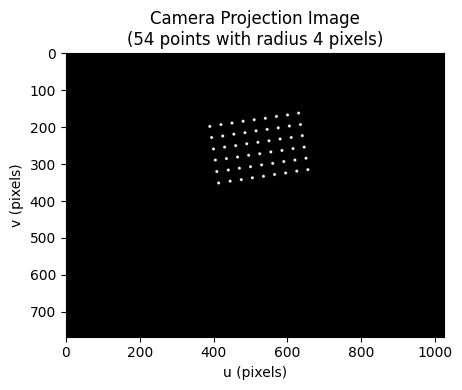

Successfully drew 54 circular points on the image
Image dimensions: 1024 x 768 pixels
Radius of each point: 4 pixels
Pose 5: 54 valid points


<Figure size 640x480 with 0 Axes>

Starting camera calibration with OpenCV...
Camera calibration successful!

PARAMETER COMPARISON

INTRINSIC PARAMETERS:
----------------------------------------
True focal length (fx, fy): (10000.00, 10000.00)
True principal point (cx, cy): (512.00, 384.00)
True distortion (k1, k2): (-0.000200, 0.000010)

Estimated focal length (fx, fy): (10000.53, 10000.53)
Estimated principal point (cx, cy): (511.80, 383.98)
Estimated distortion (k1, k2): (-0.000310, 0.014405)

Focal length error: (0.53, 0.53) pixels
Principal point error: (0.20, 0.02) pixels

EXTRINSIC PARAMETERS:
----------------------------------------

Pose 1:
  Rotation error: 0.00 degrees
  Translation error: 0.001 meters

Pose 2:
  Rotation error: 0.00 degrees
  Translation error: 0.001 meters

Pose 3:
  Rotation error: 0.00 degrees
  Translation error: 0.001 meters

CALIBRATION RESULTS SUMMARY
Number of calibration images: 5
Average points per image: 54.0

Estimated camera matrix:
[[1.00005279e+04 0.00000000e+00 5.11801257e+02

In [ ]:
# Add your code here

**Try It Yourself**

Modify the code to add more pose combinations, thereby increasing the number of calibration board images. See if this improves calibration accuracy.

# Add your summary here